In [4]:
import numpy as np
import matplotlib.pyplot as plt
from visualization import draw_field_with_robot
from particle_filter import *
from Localization_metrics import *

In [5]:
particles_count = 10000  # hyperparam: particles count 

# landmark coords
left_coord = Coord(-1, 5)
right_coord = Coord(1, 5)
lm = LandMark(left_coord, right_coord)

# standard deviation of noise for each dimension (x, y, theta)
system_noise = State(0.05, 0.05, 0.05)
sens_noise = np.array([0.3, 0.3, 0.3])

# initial state
state0 = State(0, 0, np.pi/2)

pf = ParticleFilter(particles_count, state0, lm, system_noise, sens_noise)
lm = LocalizationMetrics()

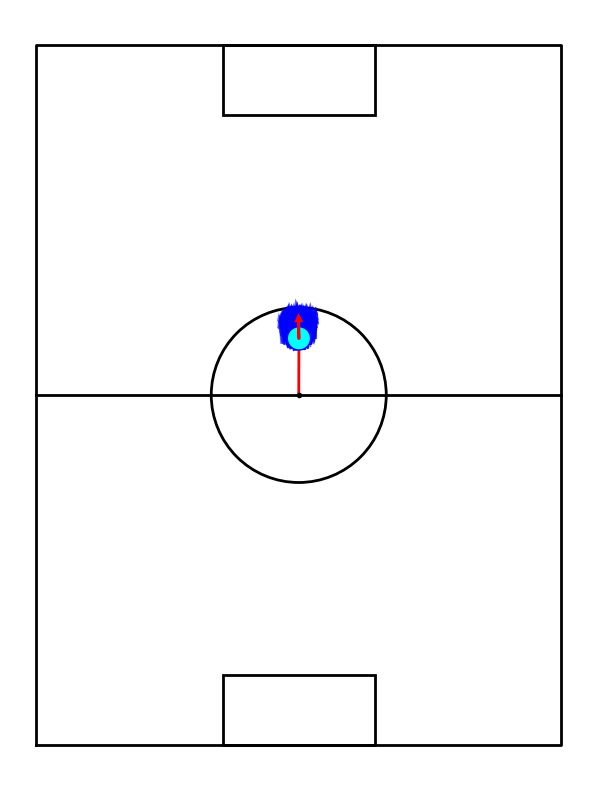

estimated state:  State(x=np.float64(0.0030620771342652875), y=np.float64(0.9710230942989062), theta=np.float64(1.5884059297664364))
true state:  State(x=np.float64(0.05820253184529874), y=np.float64(0.997657846395312), theta=1.5810423007943166)


In [6]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

steps_cnt = int(input())
trajectory = [(pf.state.x, pf.state.y)]

fig, ax = plt.subplots(figsize=(8, 10))
draw_field_with_robot(pf.state, pf.particles, particle_color='blue', ax=ax)
display(fig)

for i in range(steps_cnt):
    step = State(*map(float, input().split()))
    est_state = pf.simulate(step)

    lm.update(pf.state, est_state)
    trajectory.append((est_state.x, est_state.y))

    draw_field_with_robot(est_state, pf.particles, particle_color='blue', ax=ax)

    traj = np.array(trajectory)
    ax.plot(traj[:, 0], traj[:, 1], color='red', linewidth=2)   # от стартовой точки
    ax.plot(traj[:, 0], traj[:, 1], 'ko', markersize=3)          # узловые точки пути

    clear_output(wait=True)
    display(fig)

    print("estimated state: ", est_state)
    print("true state: ", pf.state)

plt.close(fig)

res = lm.summary()

In [7]:
res

{'position_rmse': np.float64(0.061236261846854455),
 'position_mae': np.float64(0.061236261846854455),
 'position_max': np.float64(0.061236261846854455),
 'position_final': np.float64(0.061236261846854455),
 'angle_rmse': np.float64(0.007363628972119507)}